Retail Price Optimization and Sales Forecasting

This project aims to build a predictive model that estimates product demand (quantity sold) based on various pricing factors such as own price, competitor pricing, freight costs, and product category. The objective is to simulate pricing scenarios that help drive decisions on:
*   Optimal pricing strategy
*   Impact of competitor prices
*   Category-level performance
*   Profit-maximizing price points





In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

In [3]:
from google.colab import files
uploaded =files.upload()

Saving retail_price.csv to retail_price.csv


In [4]:
df=pd.read_csv("retail_price.csv")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 676 entries, 0 to 675
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  676 non-null    object 
 1   product_category_name       676 non-null    object 
 2   month_year                  676 non-null    object 
 3   qty                         676 non-null    int64  
 4   total_price                 676 non-null    float64
 5   freight_price               676 non-null    float64
 6   unit_price                  676 non-null    float64
 7   product_name_lenght         676 non-null    int64  
 8   product_description_lenght  676 non-null    int64  
 9   product_photos_qty          676 non-null    int64  
 10  product_weight_g            676 non-null    int64  
 11  product_score               676 non-null    float64
 12  customers                   676 non-null    int64  
 13  weekday                     676 non

In [6]:
df.describe()

,qty,total_price,freight_price,unit_price,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_score,customers,...,comp_1,ps1,fp1,comp_2,ps2,fp2,comp_3,ps3,fp3,lag_price
count,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,...,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000
mean,14.495562,1422.708728,20.682270,106.496800,48.720414,767.399408,1.994083,1847.498521,4.085503,81.028107,...,79.452054,4.159467,18.597610,92.930079,4.123521,18.620644,84.182642,4.002071,17.965007,107.399684
std,15.443421,1700.123100,10.081817,76.182972,9.420715,655.205015,1.420473,2274.808483,0.232021,62.055560,...,47.933358,0.121652,9.406537,49.481269,0.207189,6.424174,47.745789,0.233292,5.533256,76.974657
min,1.000000,19.900000,0.000000,19.900000,29.000000,100.000000,1.000000,100.000000,3.300000,1.000000,...,19.900000,3.700000,0.095439,19.900000,3.300000,4.410000,19.900000,3.500000,7.670000,19.850000
25%,4.000000,333.700000,14.761912,53.900000,40.000000,339.000000,1.000000,348.000000,3.900000,34.000000,...,49.910000,4.100000,13.826429,53.900000,4.100000,14.485000,53.785714,3.900000,15.042727,55.668750
50%,10.000000,807.890000,17.518472,89.900000,51.000000,501.000000,1.500000,950.000000,4.100000,62.000000,...,69.900000,4.200000,16.618984,89.990000,4.200000,16.811765,59.900000,4.000000,16.517110,89.900000
75%,18.000000,1887.322500,22.713558,129.990000,57.000000,903.000000,2.000000,1850.000000,4.200000,116.000000,...,104.256549,4.200000,19.732500,117.888889,4.200000,21.665238,99.990000,4.100000,19.447778,129.990000
max,122.000000,12095.000000,79.760000,364.000000,60.000000,3006.000000,8.000000,9750.000000,4.500000,339.000000,...,349.900000,4.500000,57.230000,349.900000,4.400000,57.230000,255.610000,4.400000,57.230000,364.000000


In [7]:
df.isnull().sum()

,0
product_id,0
product_category_name,0
month_year,0
qty,0
total_price,0
freight_price,0
unit_price,0
product_name_lenght,0
product_description_lenght,0
product_photos_qty,0


In [8]:
df.head()

,product_id,product_category_name,month_year,qty,total_price,freight_price,unit_price,product_name_lenght,product_description_lenght,product_photos_qty,...,comp_1,ps1,fp1,comp_2,ps2,fp2,comp_3,ps3,fp3,lag_price
0,bed1,bed_bath_table,1/5/2017,1,45.95,15.100000,45.95,39,161,2,...,89.9,3.9,15.011897,215.000000,4.4,8.760000,45.95,4.0,15.100000,45.90
1,bed1,bed_bath_table,1/6/2017,3,137.85,12.933333,45.95,39,161,2,...,89.9,3.9,14.769216,209.000000,4.4,21.322000,45.95,4.0,12.933333,45.95
2,bed1,bed_bath_table,1/7/2017,6,275.70,14.840000,45.95,39,161,2,...,89.9,3.9,13.993833,205.000000,4.4,22.195932,45.95,4.0,14.840000,45.95
3,bed1,bed_bath_table,1/8/2017,4,183.80,14.287500,45.95,39,161,2,...,89.9,3.9,14.656757,199.509804,4.4,19.412885,45.95,4.0,14.287500,45.95
4,bed1,bed_bath_table,1/9/2017,2,91.90,15.100000,45.95,39,161,2,...,89.9,3.9,18.776522,163.398710,4.4,24.324687,45.95,4.0,15.100000,45.95


In [9]:
df.shape

(676, 30)

In [10]:
df['month_year'] = pd.to_datetime(df['month_year'], dayfirst=True)
df['month_year'].head()

,month_year
0,2017-05-01
1,2017-06-01
2,2017-07-01
3,2017-08-01
4,2017-09-01


Adding columns such as Revenue, Profit, and Price Difference were created to improve the model's accuracy and make the analysis easier to understand.

In [11]:
df['revenue'] = df['unit_price'] * df['qty']
df.head()

,product_id,product_category_name,month_year,qty,total_price,freight_price,unit_price,product_name_lenght,product_description_lenght,product_photos_qty,...,ps1,fp1,comp_2,ps2,fp2,comp_3,ps3,fp3,lag_price,revenue
0,bed1,bed_bath_table,2017-05-01,1,45.95,15.100000,45.95,39,161,2,...,3.9,15.011897,215.000000,4.4,8.760000,45.95,4.0,15.100000,45.90,45.95
1,bed1,bed_bath_table,2017-06-01,3,137.85,12.933333,45.95,39,161,2,...,3.9,14.769216,209.000000,4.4,21.322000,45.95,4.0,12.933333,45.95,137.85
2,bed1,bed_bath_table,2017-07-01,6,275.70,14.840000,45.95,39,161,2,...,3.9,13.993833,205.000000,4.4,22.195932,45.95,4.0,14.840000,45.95,275.70
3,bed1,bed_bath_table,2017-08-01,4,183.80,14.287500,45.95,39,161,2,...,3.9,14.656757,199.509804,4.4,19.412885,45.95,4.0,14.287500,45.95,183.80
4,bed1,bed_bath_table,2017-09-01,2,91.90,15.100000,45.95,39,161,2,...,3.9,18.776522,163.398710,4.4,24.324687,45.95,4.0,15.100000,45.95,91.90


In [12]:
df['profit'] = (df['unit_price'] - df['freight_price']) * df['qty']
df.head()

,product_id,product_category_name,month_year,qty,total_price,freight_price,unit_price,product_name_lenght,product_description_lenght,product_photos_qty,...,fp1,comp_2,ps2,fp2,comp_3,ps3,fp3,lag_price,revenue,profit
0,bed1,bed_bath_table,2017-05-01,1,45.95,15.100000,45.95,39,161,2,...,15.011897,215.000000,4.4,8.760000,45.95,4.0,15.100000,45.90,45.95,30.85
1,bed1,bed_bath_table,2017-06-01,3,137.85,12.933333,45.95,39,161,2,...,14.769216,209.000000,4.4,21.322000,45.95,4.0,12.933333,45.95,137.85,99.05
2,bed1,bed_bath_table,2017-07-01,6,275.70,14.840000,45.95,39,161,2,...,13.993833,205.000000,4.4,22.195932,45.95,4.0,14.840000,45.95,275.70,186.66
3,bed1,bed_bath_table,2017-08-01,4,183.80,14.287500,45.95,39,161,2,...,14.656757,199.509804,4.4,19.412885,45.95,4.0,14.287500,45.95,183.80,126.65
4,bed1,bed_bath_table,2017-09-01,2,91.90,15.100000,45.95,39,161,2,...,18.776522,163.398710,4.4,24.324687,45.95,4.0,15.100000,45.95,91.90,61.70


In [13]:
df['price_diff_vs_comp1'] = df['unit_price'] - df['comp_1']
df['price_diff_vs_comp2'] = df['unit_price'] - df['comp_2']
df['price_diff_vs_comp3'] = df['unit_price'] - df['comp_3']
df[['unit_price', 'qty', 'freight_price', 'revenue', 'profit',
    'price_diff_vs_comp1', 'price_diff_vs_comp2', 'price_diff_vs_comp3']].head()

,unit_price,qty,freight_price,revenue,profit,price_diff_vs_comp1,price_diff_vs_comp2,price_diff_vs_comp3
0,45.95,1,15.100000,45.95,30.85,-43.95,-169.050000,0.0
1,45.95,3,12.933333,137.85,99.05,-43.95,-163.050000,0.0
2,45.95,6,14.840000,275.70,186.66,-43.95,-159.050000,0.0
3,45.95,4,14.287500,183.80,126.65,-43.95,-153.559804,0.0
4,45.95,2,15.100000,91.90,61.70,-43.95,-117.448710,0.0


**Exploratory Data Analysis**

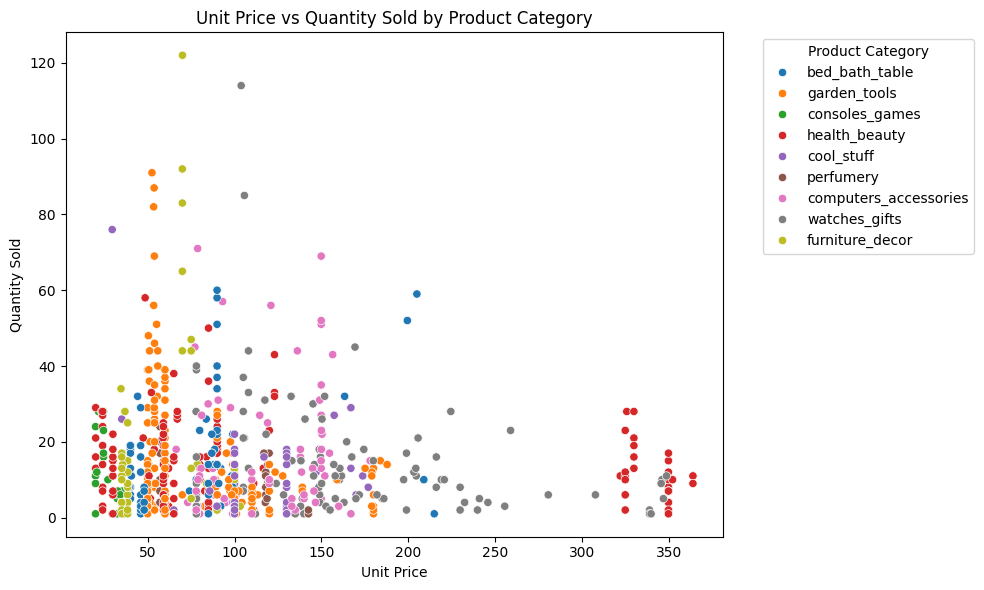

In [14]:
plt.figure(figsize=(10, 6))
scatter = sns.scatterplot(
    data=df,
    x='unit_price',
    y='qty',
    hue='product_category_name',
    palette='tab10'
)

plt.title('Unit Price vs Quantity Sold by Product Category')
plt.xlabel('Unit Price')
plt.ylabel('Quantity Sold')

plt.legend(title='Product Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

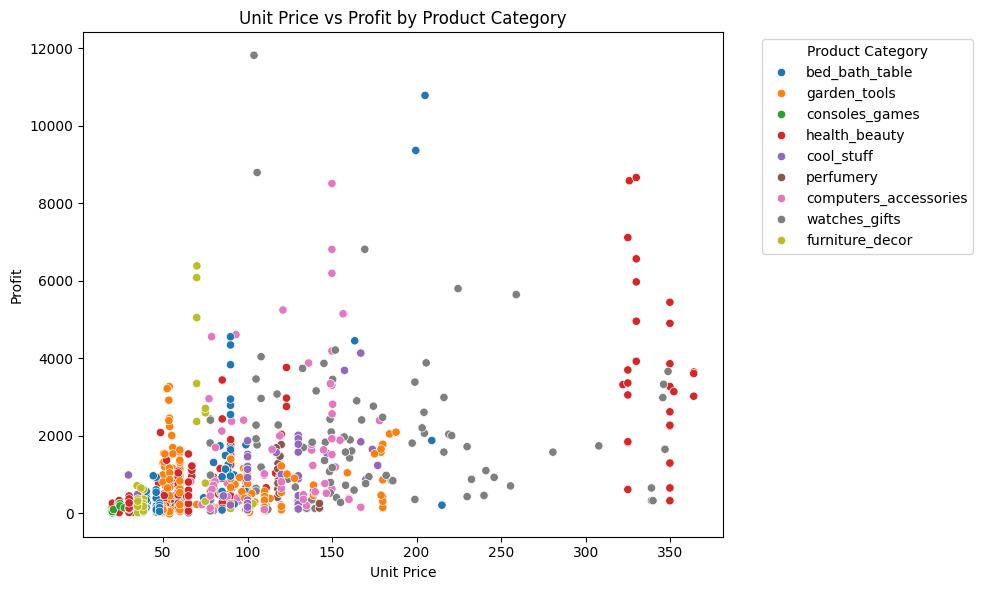

In [15]:
plt.figure(figsize=(10, 6))
scatter = sns.scatterplot(
    data=df,
    x='unit_price',
    y='profit',
    hue='product_category_name',
    palette='tab10'
)

plt.title('Unit Price vs Profit by Product Category')
plt.xlabel('Unit Price')
plt.ylabel('Profit')

plt.legend(title='Product Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

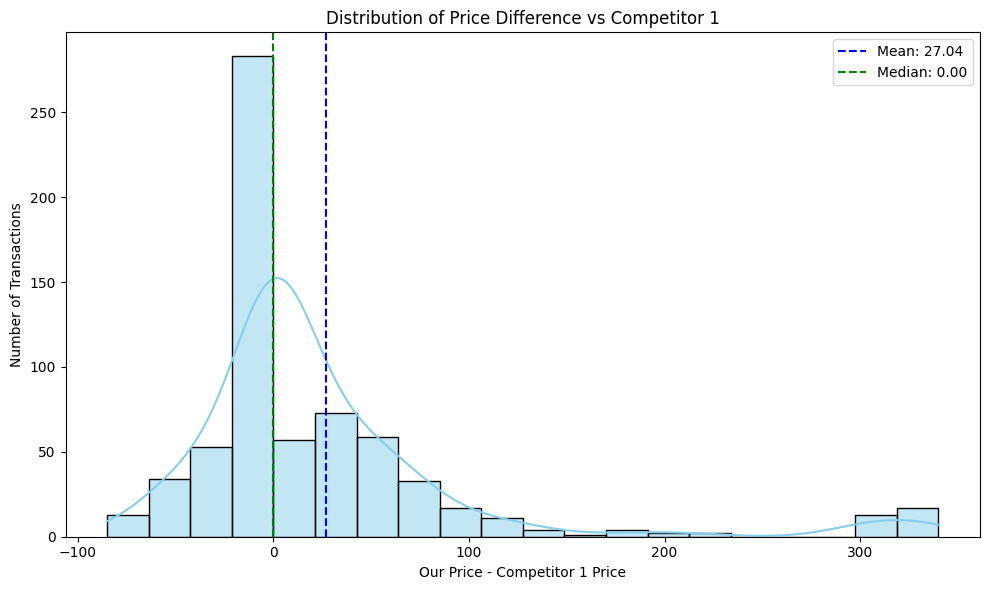

In [16]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price_diff_vs_comp1'], bins=20, kde=True, color='skyblue')
mean_diff = df['price_diff_vs_comp1'].mean()
median_diff = df['price_diff_vs_comp1'].median()
plt.axvline(mean_diff, color='blue', linestyle='--', label=f'Mean: {mean_diff:.2f}')
plt.axvline(median_diff, color='green', linestyle='--', label=f'Median: {median_diff:.2f}')
plt.title('Distribution of Price Difference vs Competitor 1')
plt.xlabel('Our Price - Competitor 1 Price')
plt.ylabel('Number of Transactions')
plt.legend()
plt.tight_layout()
plt.show()

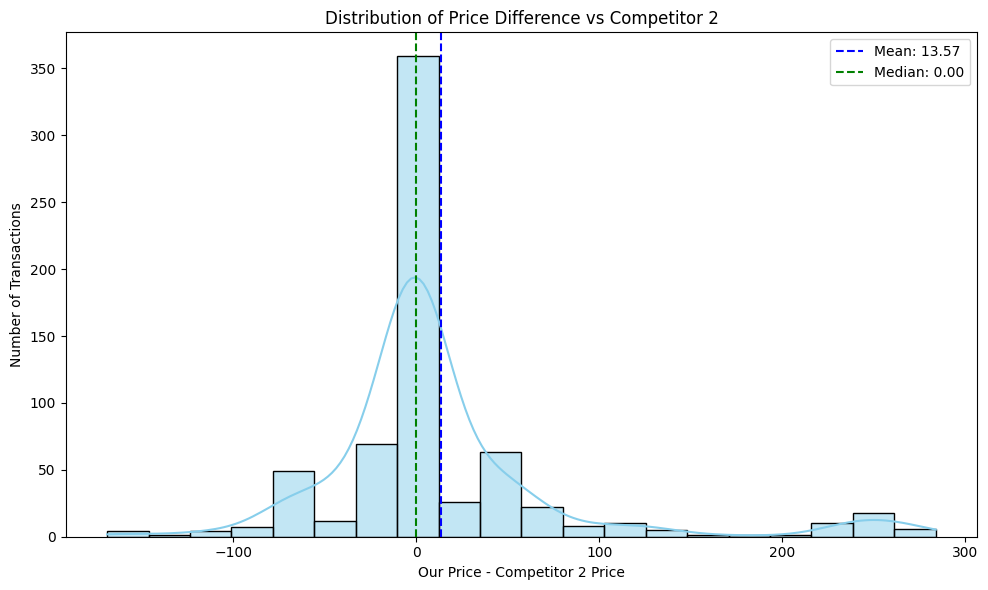

In [17]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price_diff_vs_comp2'], bins=20, kde=True, color='skyblue')
mean_diff = df['price_diff_vs_comp2'].mean()
median_diff = df['price_diff_vs_comp2'].median()
plt.axvline(mean_diff, color='blue', linestyle='--', label=f'Mean: {mean_diff:.2f}')
plt.axvline(median_diff, color='green', linestyle='--', label=f'Median: {median_diff:.2f}')
plt.title('Distribution of Price Difference vs Competitor 2')
plt.xlabel('Our Price - Competitor 2 Price')
plt.ylabel('Number of Transactions')
plt.legend()
plt.tight_layout()
plt.show()

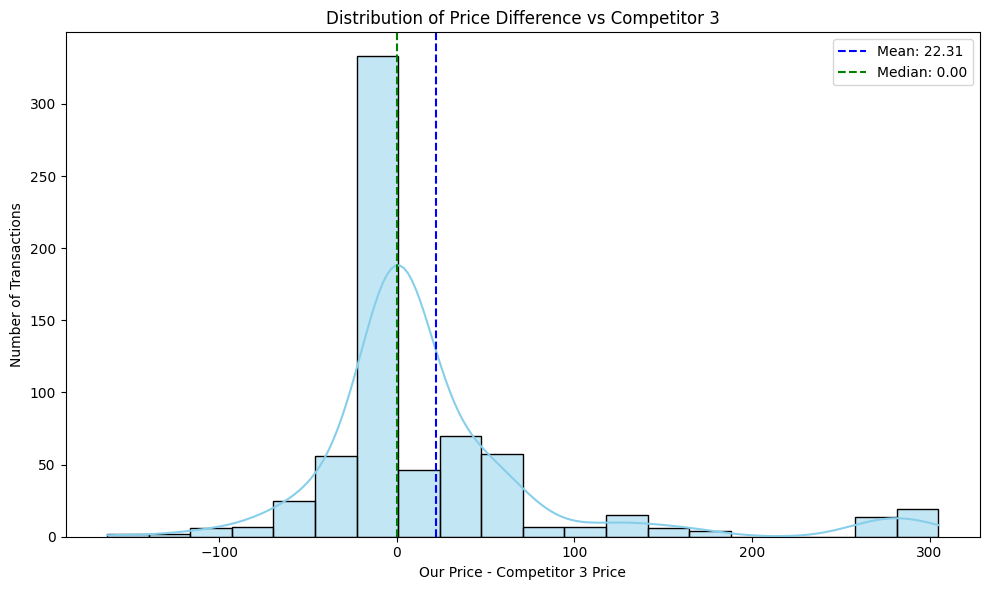

In [18]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price_diff_vs_comp3'], bins=20, kde=True, color='skyblue')
mean_diff = df['price_diff_vs_comp3'].mean()
median_diff = df['price_diff_vs_comp3'].median()
plt.axvline(mean_diff, color='blue', linestyle='--', label=f'Mean: {mean_diff:.2f}')
plt.axvline(median_diff, color='green', linestyle='--', label=f'Median: {median_diff:.2f}')
plt.title('Distribution of Price Difference vs Competitor 3')
plt.xlabel('Our Price - Competitor 3 Price')
plt.ylabel('Number of Transactions')
plt.legend()
plt.tight_layout()
plt.show()

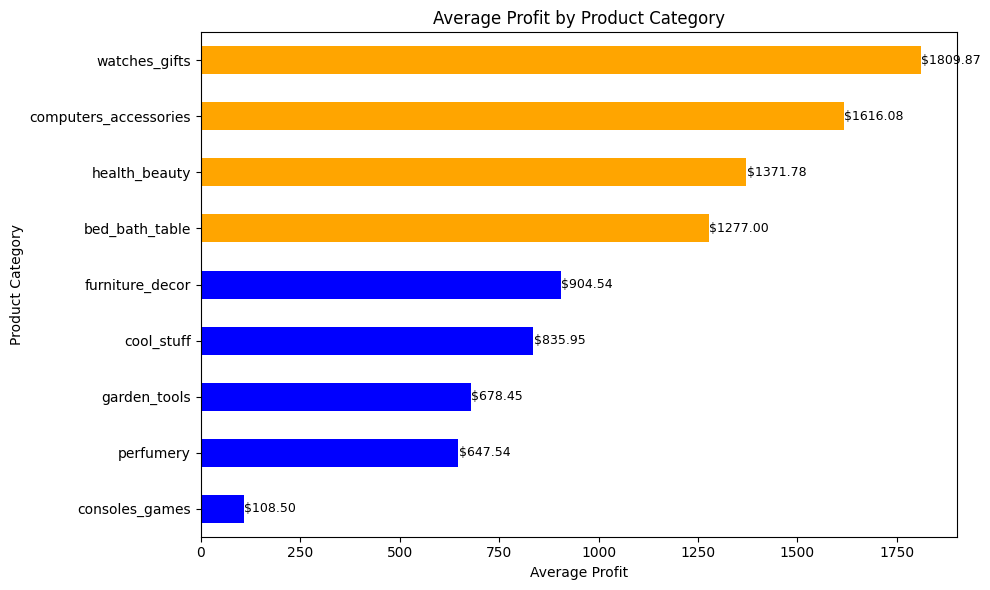

In [19]:
category_profit = df.groupby('product_category_name')['profit'].mean().sort_values()
plt.figure(figsize=(10, 6))

colors = ['blue' if val < 1000 else 'orange' for val in category_profit]

bars = category_profit.plot(kind='barh', color=colors)
plt.title('Average Profit by Product Category')
plt.xlabel('Average Profit')
plt.ylabel('Product Category')

for index, value in enumerate(category_profit):
    plt.text(value + 1, index, f'${value:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

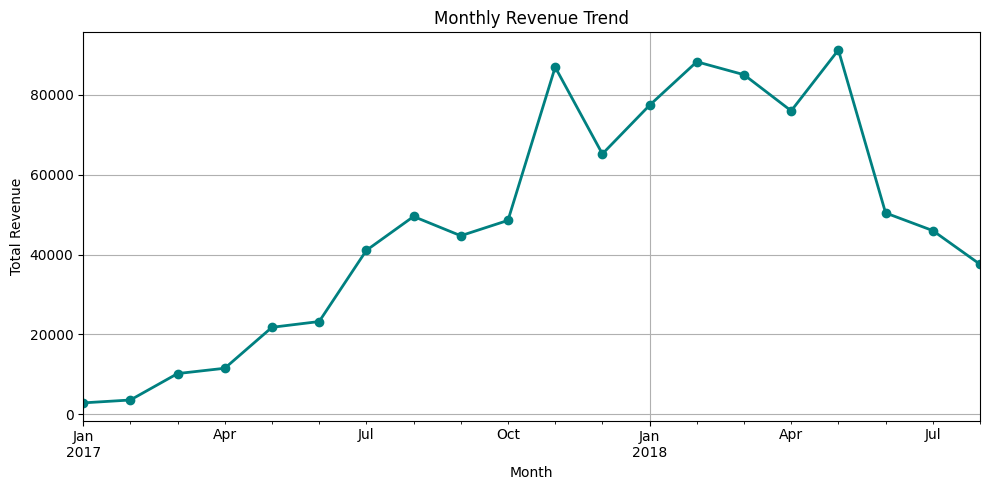

In [20]:
monthly_revenue = df.groupby('month_year')['revenue'].sum()
plt.figure(figsize=(10, 5))
monthly_revenue.plot(marker='o', color='teal', linewidth=2)
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.grid(True)
plt.tight_layout()
plt.show()


## Model Training: XGBoost Regressor
XGBoost Regressor is a machine learning algorithm used to predict continuous numerical values, such as Product demand because it provides accurate results for structured retail data.

The model was evaluated using the following metrics:

* **MAE (Mean Absolute Error):** Measures the average difference between predicted and actual demand.
* **RMSE (Root Mean Squared Error):** Gives more weight to larger prediction errors.
* **MAPE (Mean Absolute Percentage Error):** Shows the prediction error as a percentage.

The trained model helps forecast future product demand, allowing businesses to make better pricing, inventory, and sales planning decisions.




In [21]:
df['month_year'] = pd.to_datetime(df['month_year'], dayfirst=True)
df['month'] = df['month_year'].dt.month
df['year'] = df['month_year'].dt.year
df['quarter'] = df['month_year'].dt.quarter

category_dummies = pd.get_dummies(df['product_category_name'], drop_first=True)

X_numeric = df[['unit_price', 'comp_1', 'comp_2', 'comp_3', 'freight_price', 'month', 'year', 'quarter']]
X = pd.concat([X_numeric, category_dummies], axis=1)
X = X.astype("float64")

df['log_qty'] = np.log1p(df['qty'])
y = df['log_qty']

X_train, X_test, y_train, y_test_raw = train_test_split(X, y, test_size=0.2, random_state=42)

model = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
model.fit(X_train, y_train)

y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_test = np.expm1(y_test_raw)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"\n📊 Final Model Performance (on original qty scale):")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")


📊 Final Model Performance (on original qty scale):
MAE: 8.01
RMSE: 11.61
MAPE: 156.91%


# **Model Evaluation**
The model is evaluated on the test set. Predictions are transformed back from the log scale. Here's how well it performed in predicting quantity sold:

* MAE (Mean Absolute Error): Average number of units off
* RMSE (Root Mean Squared Error): Heavily penalizes larger errors
* MAPE (Mean Absolute Percentage Error): Percentage error relative to actual quantity

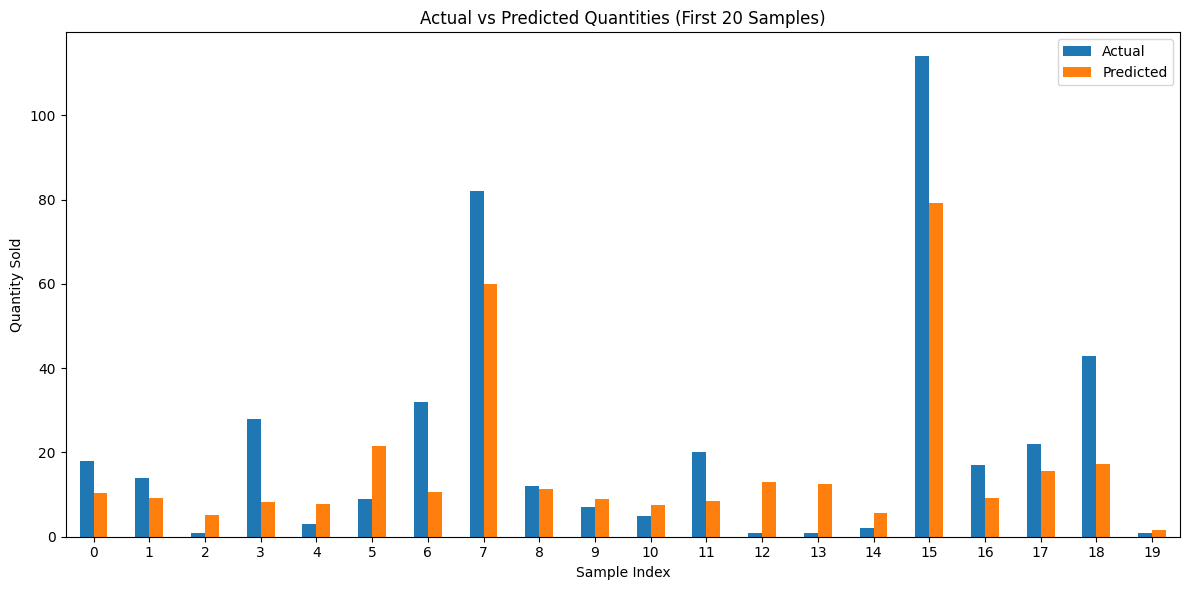

In [22]:
sample = pd.DataFrame({
    'Actual': y_test.values[:20],
    'Predicted': y_pred[:20]
}).reset_index(drop=True)

sample.plot(kind='bar', figsize=(12, 6))
plt.title("Actual vs Predicted Quantities (First 20 Samples)")
plt.xlabel("Sample Index")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## **Feature Importance**
XGBoost provides a built-in feature importance metric, which we use to understand which features most influence demand prediction.

In [23]:
def simulate_price_scenario(new_price, unit_cost, comp1, comp2, comp3, freight, category, month=1, year=2023, quarter=None):
    if quarter is None:
        quarter = (month - 1) // 3 + 1

    input_dict = {
        'unit_price': [new_price],
        'comp_1': [comp1],
        'comp_2': [comp2],
        'comp_3': [comp3],
        'freight_price': [freight],
        'month': [month],
        'year': [year],
        'quarter': [quarter],
    }

    for col in category_dummies.columns:
        input_dict[col] = [1 if col == category else 0]

    input_df = pd.DataFrame(input_dict)
    input_df = input_df[X.columns]

    log_pred = model.predict(input_df)
    qty_pred = np.expm1(log_pred[0])

    profit = (new_price - unit_cost - freight) * qty_pred

    return round(qty_pred, 2), round(profit, 2)

Change the values below to simulate What-if scenarios better

In [24]:
qty, profit = simulate_price_scenario(
    new_price=55,
    unit_cost=30,
    comp1=65,
    comp2=45,
    comp3=55,
    freight=10,
    category='computers_accessories',
    month=4,
    year=2025
)

print(f"Predicted Quantity: {qty}")
print(f"Estimated Profit: ${profit}")

Predicted Quantity: 25.719999313354492
Estimated Profit: $385.7799987792969


In [25]:
df_export = df.copy()
df_export['month_year'] = pd.to_datetime(df_export['month_year'], dayfirst=True)
df_export['price_diff_vs_comp1'] = df_export['unit_price'] - df_export['comp_1']
df_export['price_diff_vs_comp2'] = df_export['unit_price'] - df_export['comp_2']
df_export['price_diff_vs_comp3'] = df_export['unit_price'] - df_export['comp_3']
df_export['profit'] = (df_export['unit_price'] - df_export['freight_price']) * df_export['qty']

selected_cols = [
    'month_year', 'product_category_name', 'unit_price', 'comp_1', 'comp_2', 'comp_3',
    'price_diff_vs_comp1', 'price_diff_vs_comp2', 'price_diff_vs_comp3',
    'qty', 'freight_price', 'profit'
]

#Now Save Dataset
df_export[selected_cols].to_csv("retail_price_processed.csv", index=False)

**Conclusion**

* The model successfully predicts quantity sold with reasonable accuracy.
* Features like own price, freight cost, and competitor pricing significantly influence demand.
* The simulator can be used by pricing teams to test different strategies for each category.